In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from black_scholes.pinn.bs_pinn import BlackScholesPINN
from utility.model import ModelConfig

from black_scholes.tree.tree import BinomialTree
from utility.plot import plot_price_heatmaps

from utility.continuation_prob import continuation_normal, compute_continuation_probs

In [2]:
r = 0.1
sigma = 0.3
K = 1.0
T = 1.0
S_min = 0.0
S_max = 3 * K

input_size = 2
hidden_sizes = [32, 32, 32]
output_size = 1
activation = nn.Sigmoid()
learning_rate = 0.001

step_size = 2000
gamma = 0.7

model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate,
    step_size=step_size,
    gamma=gamma
)

seeds = np.arange(40, 65)
pinns = []

for seed in seeds:
    pinn = BlackScholesPINN(model_config, seed=seed)
    pinn.set_params(K, r, sigma, T, S_min, S_max)

    pinn.load(f'../models/bs_pinn_1d/{seed}.pth')
    pinns.append(pinn)

## Compare with binomial Tree

In [3]:
bt = BinomialTree(K, r, T, sigma, n_steps=100)

In [4]:
# grid resolution
num_S = 80
num_T = 80

Ss = np.linspace(S_min, S_max, num_S)
Ts = np.linspace(0, T-1e-4, num_T)  # avoid exactly zero maturity

bt_prices = np.loadtxt('../black_scholes/tree/bt_prices.txt')
nn_prices_all = np.zeros((len(seeds), num_T, num_S))

for i, pinn in enumerate(pinns):
    nn_prices = np.zeros((num_T, num_S))
    for j, t_val in enumerate(Ts):
        t_tensor = torch.full((num_S,), t_val)
        nn_prices[j, :] = pinn.predict(t_tensor, Ss).squeeze().numpy()
    nn_prices_all[i, :, :] = nn_prices

In [5]:
# Get mean and std across seeds
nn_prices_mean = np.mean(nn_prices_all, axis=0)
nn_prices_std = np.std(nn_prices_all, axis=0, ddof=1)


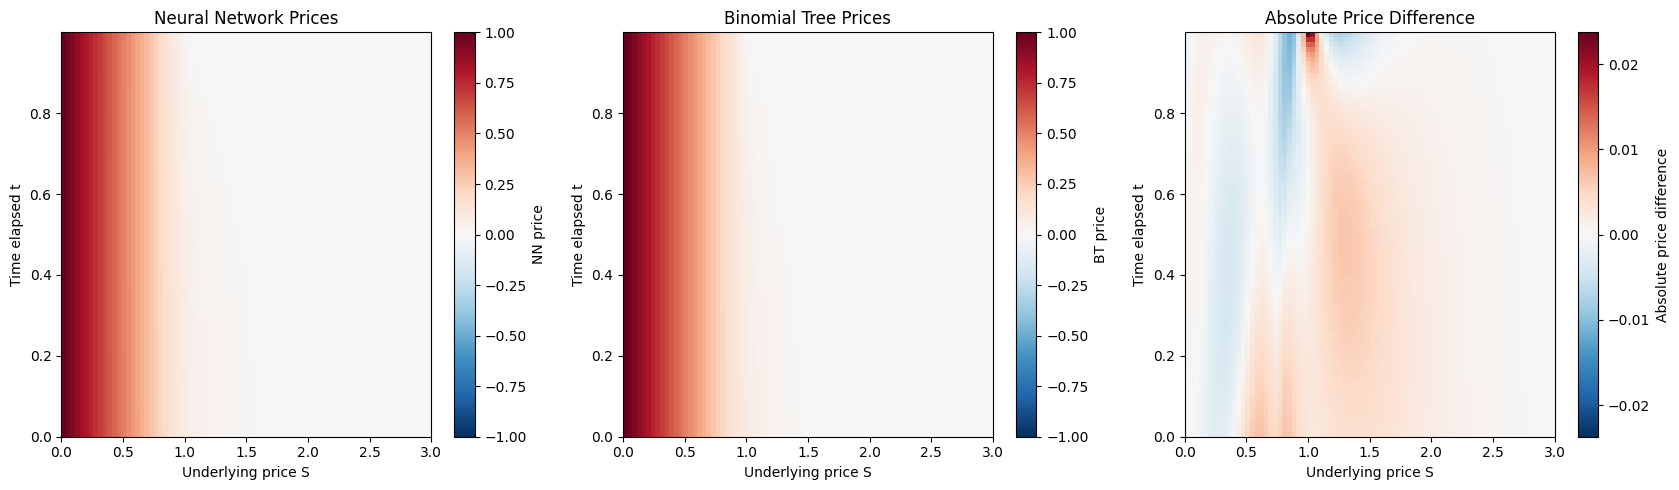

In [6]:
# Visualise the mean price surfaces
plot_price_heatmaps(
    prices1=nn_prices_mean, prices2=bt_prices,
    xlabel='Underlying price S', ylabel='Time elapsed t',
    title1='Neural Network Prices', title2='Binomial Tree Prices', title_diff='Absolute Price Difference',
    label1='NN price', label2='BT price', label_diff='Absolute price difference',
    extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]]
)

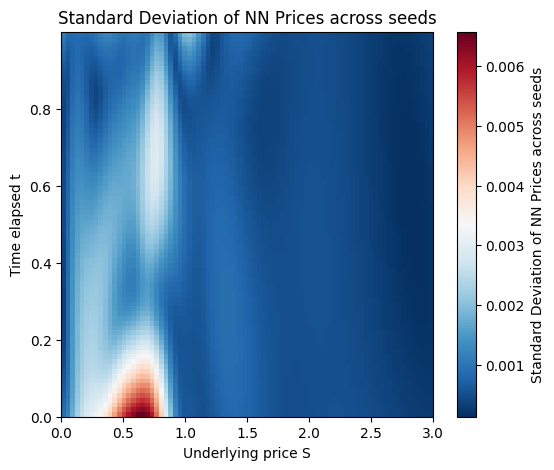

In [7]:
# Visualise the standard deviation

plt.figure(figsize=(6, 5))
plt.imshow(nn_prices_std, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]], origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Standard Deviation of NN Prices across seeds')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Standard Deviation of NN Prices across seeds')
plt.show()

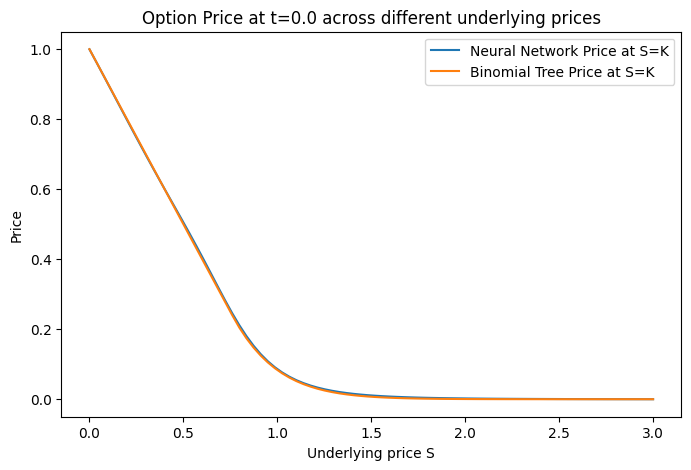

In [8]:
# Error at time 0
t_ind = 0

nn_prices_t0 = nn_prices_mean[t_ind, :]
bt_prices_t0 = bt_prices[t_ind, :]

plt.figure(figsize=(8, 5))
plt.plot(Ss, nn_prices_t0, label='Neural Network Price at S=K')
plt.plot(Ss, bt_prices_t0, label='Binomial Tree Price at S=K')
plt.xlabel('Underlying price S')
plt.ylabel('Price')
plt.title(f'Option Price at t={Ts[t_ind]} across different underlying prices')
plt.legend()
plt.show()

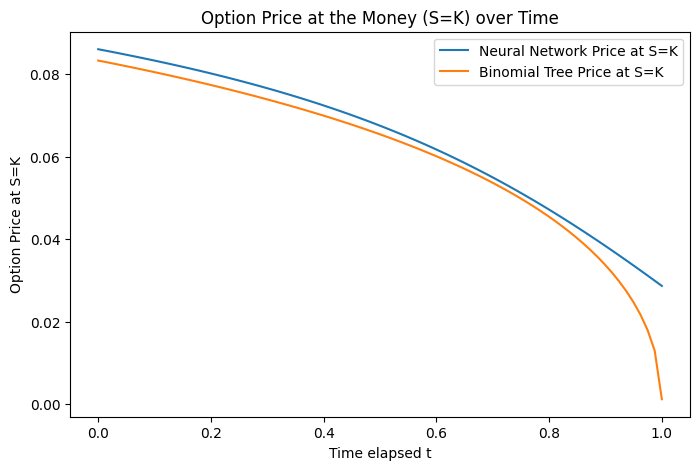

In [9]:
# Error at the money
pinn = pinns[1]  # just pick one seed for the ATM plot

S_try = K
nn_prices_atm = np.array([pinn.predict(t, S_try).item() for t in Ts])
bt_prices_atm = np.array([bt.predict(t, S_try) for t in Ts])

plt.figure(figsize=(8, 5))
plt.plot(Ts, nn_prices_atm, label='Neural Network Price at S=K')
plt.plot(Ts, bt_prices_atm, label='Binomial Tree Price at S=K')
plt.xlabel('Time elapsed t')
plt.ylabel('Option Price at S=K')
plt.title('Option Price at the Money (S=K) over Time')
plt.legend()
plt.show()

### Continuation probabilities

Identify distribution of neural network solutions (test for gaussianity)

In [10]:
nn_prices_standardised = (nn_prices_all - nn_prices_mean) / nn_prices_std

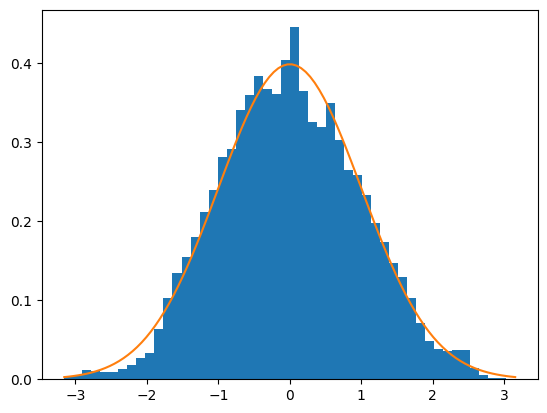

In [11]:
# plot standard normal
from scipy.stats import norm

x_min = np.min(nn_prices_standardised)
x_max = np.max(nn_prices_standardised)
x = np.linspace(x_min, x_max, 100)

plt.hist(nn_prices_standardised.flatten(), bins=50, density=True)
plt.plot(x, norm.pdf(x), label='Standard Normal PDF')

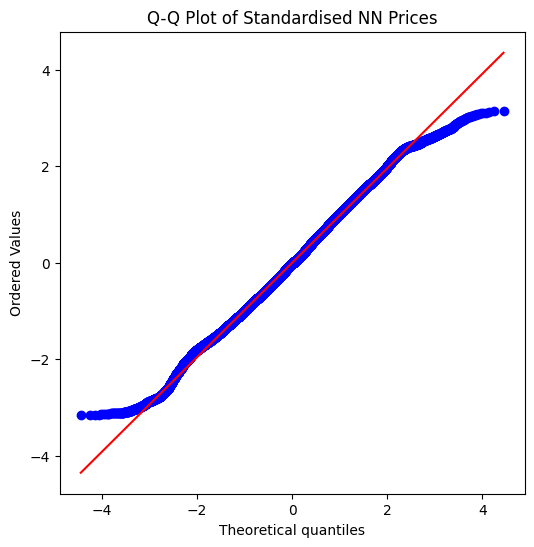

In [12]:
## qq plot
from scipy.stats import probplot
plt.figure(figsize=(6, 6))
probplot(nn_prices_standardised.flatten(), dist="norm", plot=plt)
plt.title('Q-Q Plot of Standardised NN Prices')
plt.show()

Binomial tree continuation probabilities

/Users/jameswu/Documents/Imperial/Year 4/M4R/utility/continuation_prob.py:52: RuntimeWarning: divide by zero encountered in divide
  stds > 0, norm.cdf((prices - intrinsics) / stds),  # std > 0 use CDF
/Users/jameswu/Documents/Imperial/Year 4/M4R/utility/continuation_prob.py:52: RuntimeWarning: invalid value encountered in divide
  stds > 0, norm.cdf((prices - intrinsics) / stds),  # std > 0 use CDF


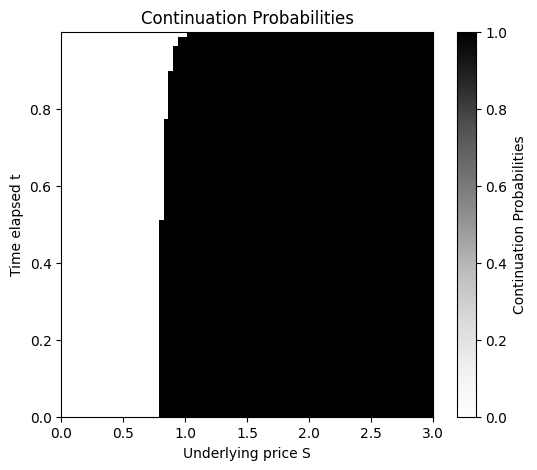

In [13]:
intrinsics = np.tile(np.maximum(K - Ss, 0), (num_T, 1))
continuation_probs_bt = continuation_normal(bt_prices, np.zeros_like(bt_prices), intrinsics)
plt.figure(figsize=(6, 5))
plt.imshow(continuation_probs_bt, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
           origin='lower', aspect='auto', cmap='Greys')
plt.colorbar(label='Continuation Probabilities')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Continuation Probabilities')
plt.show()

In [14]:
num_S_ = 200
num_T_ = 200

Ss_ = np.linspace(0, 1, num_S_)
Ts_ = np.linspace(0, T-1e-4, num_T_)  # avoid exactly zero maturity

nn_prices_all_ = np.zeros((len(seeds), num_T_, num_S_))

for i, pinn in enumerate(pinns):
    nn_prices = np.zeros((num_T_, num_S_))
    for j, t_val in enumerate(Ts_):
        t_tensor = torch.full((num_S_,), t_val)
        nn_prices[j, :] = pinn.predict(t_tensor, Ss_).squeeze().numpy()
    nn_prices_all_[i, :, :] = nn_prices

nn_prices_mean_ = np.mean(nn_prices_all_, axis=0)
nn_prices_std_ = np.std(nn_prices_all_, axis=0, ddof=1) / np.sqrt(len(seeds))

In [15]:
intrinsics_ = np.tile(np.maximum(K - Ss_, 0), (num_T_, 1))
continuation_probs = continuation_normal(nn_prices_mean_, nn_prices_std_, intrinsics_)

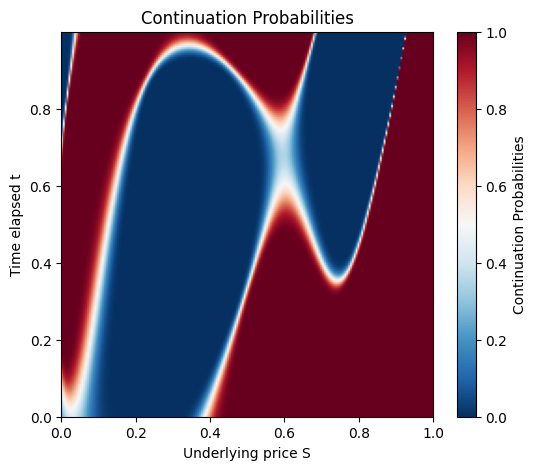

In [16]:
plt.figure(figsize=(6, 5))
plt.imshow(continuation_probs, extent=[Ss_[0], Ss_[-1], Ts_[0], Ts_[-1]],
           origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Continuation Probabilities')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Continuation Probabilities')
plt.show()

/Users/jameswu/Documents/Imperial/Year 4/M4R/utility/continuation_prob.py:35: RuntimeWarning: divide by zero encountered in divide
  d = (prices - intrinsics + shift) / intrinsics


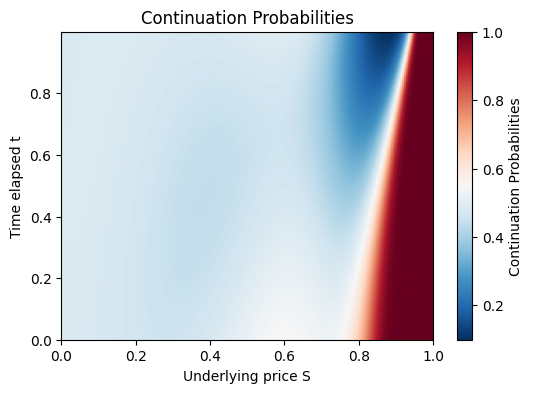

In [17]:
cp = compute_continuation_probs(nn_prices_mean_, intrinsics_, eps1=1e-1, eps2=1e-1, one=0.9, shift=-0.003)
plt.figure(figsize=(6, 4))
plt.imshow(cp, extent=[Ss_[0], Ss_[-1], Ts_[0], Ts_[-1]],
           origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Continuation Probabilities')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Continuation Probabilities')
plt.show()